In [120]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

In [121]:
!pip install kagglehub

In [122]:
import kagglehub  # Library used to download datasets directly from Kaggle

# Download the "maternaworkloadtraces" dataset from Kaggle
# The dataset is identified by the owner (kpiyush04) and dataset name (maternaworkloadtraces)
path = kagglehub.dataset_download("kpiyush04/maternaworkloadtraces")

# Display the local path where the dataset has been downloaded
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/kpiyush04/maternaworkloadtraces


In [123]:
import os 
# Move into the first directory found inside the current path
path = path + "/" + os.listdir(path)[0]

# Create a list containing the full paths of all directories/files inside the path
dirs = [os.path.join(path, dir) for dir in os.listdir(path)]

# List that will store all valid DataFrames
dfs = []

# Walk through the directory tree
for root, dirs, files in os.walk(path):

    # Iterate through all files in the current directory
    for file in files:
        # Process only CSV files
        if file.endswith(".csv"):
            try:
                # Load the CSV file using ';' as separator and '.' as decimal symbol
                df = pd.read_csv(
                    os.path.join(root, file),
                    delimiter=";",
                    decimal='.'
                )

                # Clean and convert resource usage columns to numeric values
                for col in ['Memory usage [%]', 'CPU usage [%]']:

                    # Convert values to strings, replace commas with dots,
                    # remove whitespace, and prepare for numeric conversion
                    df[col] = (
                        df[col]
                        .astype(str)
                        .str.replace(",", ".")
                        .str.replace(r"\s+", "", regex=True)
                    )

                    # Convert cleaned values to numeric type
                    # Invalid values become NaN
                    df[col] = pd.to_numeric(df[col], errors='coerce')

                # Calculate the proportion of rows where memory usage is 0
                zero_mem = (df['Memory usage [%]'] == 0).mean()

                # Calculate the proportion of rows where CPU usage is 0
                zero_cpu = (df['CPU usage [%]'] == 0).mean()

                # Keep only datasets where less than 40% of values are zeros
                # for both memory and CPU usage
                if zero_mem < 0.4 and zero_cpu < 0.4:
                    dfs.append(df)

            except:
                # Handle any file loading or processing errors
                print("cannot load data")

# Display the number of successfully loaded DataFrames
print("loaded files : ", len(dfs))


loaded files :  1473


In [124]:
dfs[0].head()

,Timestamp,CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],CPU usage [%],Memory capacity provisioned [KB],Memory usage [KB],Memory usage [%],Disk read throughput [KB/s],Disk write throughput [KB/s],Disk size [GB],Network received throughput [KB/s],Network transmitted throughput [KB/s]
0,04.01.2016 00:00:00,2,0,81,1.71,4194304,33135,0.79,0,4,34,0,0
1,04.01.2016 00:05:00,2,0,80,1.67,4194304,63753,1.52,0,6,34,0,0
2,04.01.2016 00:10:00,2,0,85,1.77,4194304,100244,2.39,7,8,34,0,0
3,04.01.2016 00:15:00,2,0,80,1.68,4194304,41524,0.99,0,5,34,0,0
4,04.01.2016 00:20:00,2,0,82,1.71,4194304,41524,0.99,0,4,34,0,0


In [125]:
import datetime

# Iterate through all DataFrames stored in the dfs list
for i in range(len(dfs)):

    # Convert the Timestamp column from string format to a datetime object
    dfs[i]['Time'] = pd.to_datetime(
        dfs[i]['Timestamp'],
        format="%d.%m.%Y %H:%M:%S"
    )

    # Set the newly created Time column as the DataFrame index
    dfs[i].set_index('Time', inplace=True)

    # Sort rows chronologically based on the datetime index
    dfs[i].sort_index(inplace=True)

    # ---------------------------------------------------
    # Feature Engineering: Extract time-based features
    # ---------------------------------------------------

    # Extract hour of the day (0-23)
    dfs[i]['hour'] = dfs[i].index.hour.astype(int)

    # Extract day of the month (1-31)
    dfs[i]['day'] = dfs[i].index.day.astype(int)

    # Extract day of the week
    # Monday = 0, Tuesday = 1, ..., Sunday = 6
    dfs[i]['weekday'] = dfs[i].index.weekday.astype(int)

    # Remove the original Timestamp column since it is no longer needed
    dfs[i] = dfs[i].drop(['Timestamp'], axis=1)

# Display the first five rows of the first DataFrame
dfs[0].head()

,CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],CPU usage [%],Memory capacity provisioned [KB],Memory usage [KB],Memory usage [%],Disk read throughput [KB/s],Disk write throughput [KB/s],Disk size [GB],Network received throughput [KB/s],Network transmitted throughput [KB/s],hour,day,weekday
Time,,,,,,,,,,,,,,,
2016-01-04 00:00:00,2,0,81,1.71,4194304,33135,0.79,0,4,34,0,0,0,4,0
2016-01-04 00:05:00,2,0,80,1.67,4194304,63753,1.52,0,6,34,0,0,0,4,0
2016-01-04 00:10:00,2,0,85,1.77,4194304,100244,2.39,7,8,34,0,0,0,4,0
2016-01-04 00:15:00,2,0,80,1.68,4194304,41524,0.99,0,5,34,0,0,0,4,0
2016-01-04 00:20:00,2,0,82,1.71,4194304,41524,0.99,0,4,34,0,0,0,4,0


In [126]:
for i in range(len(dfs)):
  for col in dfs[0].columns :
    if dfs[i][col].dtype == "object":
        dfs[i][col] = (
            dfs[i][col]
            .astype(str)
            .str.replace('"', '')           # remove quotes
            .str.replace(",", ".")         # comma → dot
            .str.replace(r"\s+", "", regex=True)  # remove spaces
        )
        try:
            dfs[i][col] = dfs[i][col].astype(float)
        except:
            pass
dfs[0].head()

,CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],CPU usage [%],Memory capacity provisioned [KB],Memory usage [KB],Memory usage [%],Disk read throughput [KB/s],Disk write throughput [KB/s],Disk size [GB],Network received throughput [KB/s],Network transmitted throughput [KB/s],hour,day,weekday
Time,,,,,,,,,,,,,,,
2016-01-04 00:00:00,2,0,81,1.71,4194304,33135,0.79,0,4,34,0,0,0,4,0
2016-01-04 00:05:00,2,0,80,1.67,4194304,63753,1.52,0,6,34,0,0,0,4,0
2016-01-04 00:10:00,2,0,85,1.77,4194304,100244,2.39,7,8,34,0,0,0,4,0
2016-01-04 00:15:00,2,0,80,1.68,4194304,41524,0.99,0,5,34,0,0,0,4,0
2016-01-04 00:20:00,2,0,82,1.71,4194304,41524,0.99,0,4,34,0,0,0,4,0


In [127]:
import pandas as pd
import numpy as np

# Iterate through all DataFrames in the dfs list
for i in range(len(dfs)):

    # ---------------------------------------------------
    # CPU Capacity Calculation
    # ---------------------------------------------------
    # Estimate the provisioned CPU capacity (in MHz)
    # using CPU usage in MHz and CPU usage percentage.
    dfs[i]['CPU capacity provisioned [MHZ]'] = (
        dfs[i]['CPU usage [MHZ]'] * 100
    ) / dfs[i]['CPU usage [%]']

    # ---------------------------------------------------
    # Lag Features
    # ---------------------------------------------------
    # Lag features provide historical values to help
    # the model learn temporal dependencies.

    # CPU usage one time step before
    dfs[i]['cpu_lag1'] = dfs[i]['CPU usage [%]'].shift(1)

    # CPU usage three time steps before
    # (Variable name says lag5, but shift(3) creates a lag of 3)
    dfs[i]['cpu_lag3'] = dfs[i]['CPU usage [%]'].shift(3)

    # Memory usage one time step before
    dfs[i]['memory_lag1'] = dfs[i]['Memory usage [%]'].shift(1)

    # Memory usage three time steps before
    # (Variable name says lag5, but shift(3) creates a lag of 3)
    dfs[i]['memory_lag3'] = dfs[i]['Memory usage [%]'].shift(3)

    # ---------------------------------------------------
    # Rolling Statistics for CPU Usage
    # ---------------------------------------------------
    # Calculate moving average and standard deviation
    # over a rolling window of 3 observations.

    # Rolling mean of CPU usage
    dfs[i]['cpu_mean'] = dfs[i]['CPU usage [%]'].rolling(3).mean()

    # Rolling standard deviation of CPU usage
    dfs[i]['cpu_std'] = dfs[i]['CPU usage [%]'].rolling(3).std()

    # ---------------------------------------------------
    # Rolling Statistics for Memory Usage
    # ---------------------------------------------------

    # Rolling mean of memory usage
    dfs[i]['memory_mean'] = dfs[i]['Memory usage [%]'].rolling(3).mean()

    # Rolling standard deviation of memory usage
    dfs[i]['memory_std'] = dfs[i]['Memory usage [%]'].rolling(3).std()


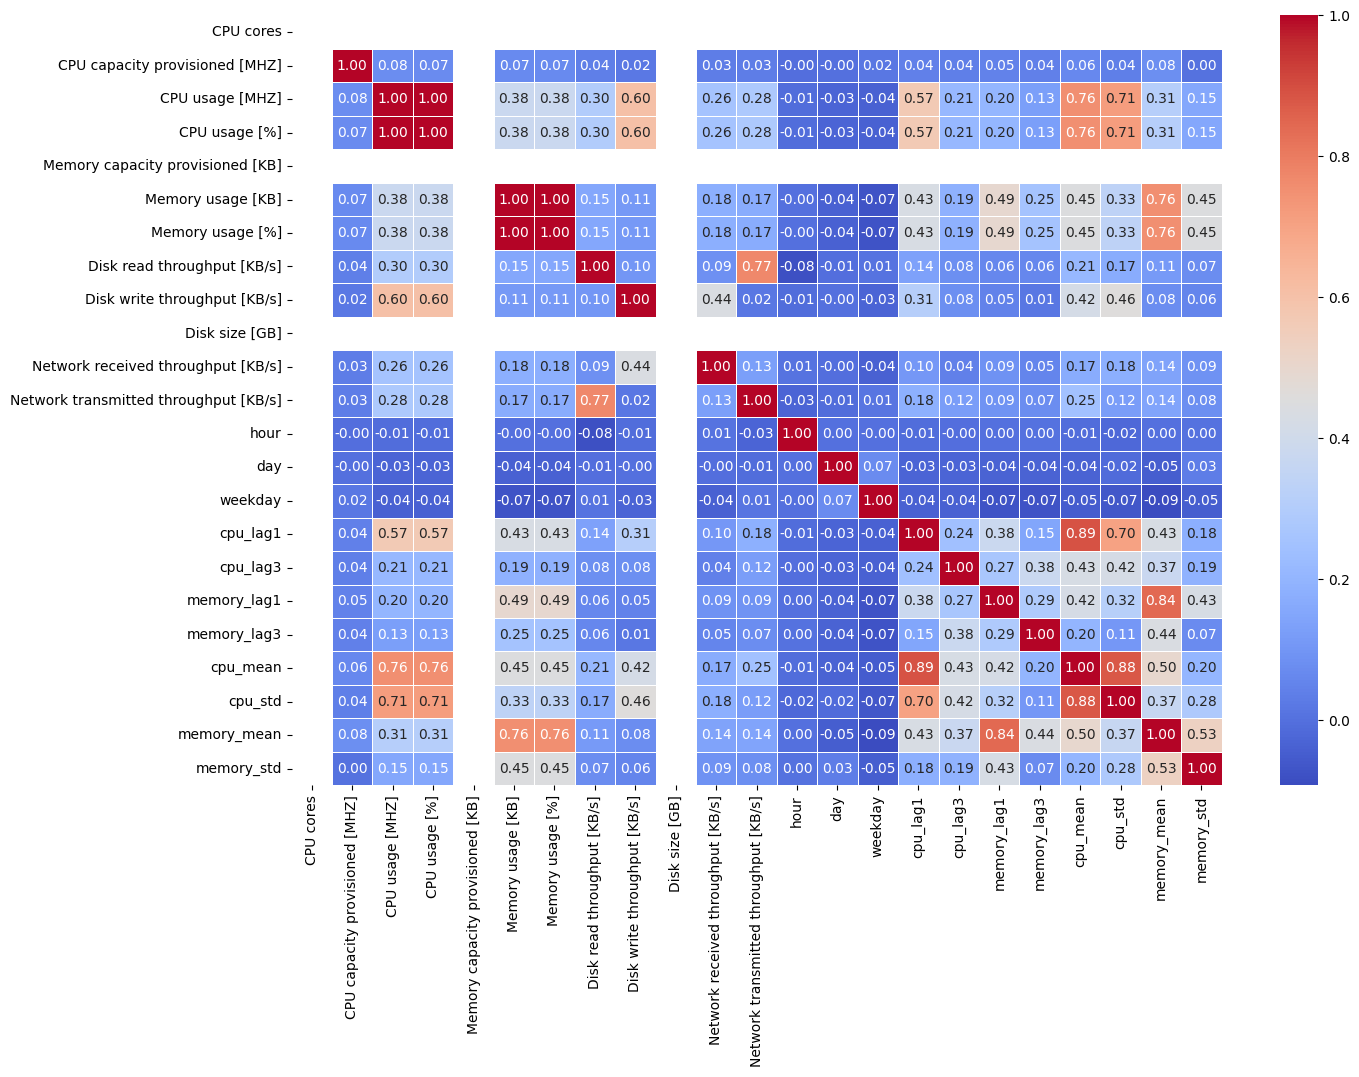

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = dfs[i].corr()
plt.figure(figsize=(15,10),dpi=100)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.show()

In [129]:
# ---------------------------------------------------
# Feature Selection and Dataset Consolidation
# ---------------------------------------------------

for i in range(len(dfs)):

    # Remove features that will not be used during model training.
    # These metrics are either redundant, highly correlated with
    # other variables, or not relevant to the prediction task.

    dfs[i] = dfs[i].drop(
        [
            'CPU usage [MHZ]',                    # Raw CPU consumption in MHz
            'Memory usage [KB]',                  # Raw memory consumption in KB
            'hour', 
            'day',
            'weekday' ,
            'CPU capacity provisioned [MHZ]',
        ],
        axis=1
    )

# ---------------------------------------------------
# Merge All DataFrames
# ---------------------------------------------------
# Combine the processed DataFrames into a single dataset.
# The index is reset to create a continuous row numbering.

df = pd.concat(dfs, ignore_index=True)

In [130]:
# ---------------------------------------------------
# Column Name Cleaning
# ---------------------------------------------------
# This step sanitizes column names by removing special characters
# that may cause issues in ML pipelines, SQL databases, or APIs.

for col in df.columns:

    # Check if the column name contains special characters
    # that should be removed for compatibility:
    # [ ] < > %
    if (
        "[" in col or
        "]" in col or
        ">" in col or
        "<" in col or
        "%" in col
    ):

        # Create a cleaned version of the column name
        new_col = (
            col.replace("[", "")
               .replace("]", "")
               .replace(">", "")
               .replace("<", "")
               .replace("%", "")
               .strip()
        )

        # Assign the cleaned column as a new column
        df[new_col] = df[col]

        # Remove the original column with special characters
        df = df.drop([col], axis=1)

In [131]:
# =========================================================
# CREATE TARGET VARIABLES
# =========================================================
# The objective is to predict the next time step's CPU and memory usage based on historical metrics.
# shift(-1) moves the values one row upward, making each row contain the resource usage value that occurs immediately after the current observation.

df["target_cpu"] = df["CPU usage"].shift(-1)
df["target_memory"] = df["Memory usage"].shift(-1)

# Remove rows containing NaN values.
# NaN values appear in:
# - Lag features (at the beginning of the dataset)
# - Rolling statistics (first observations)
# - Target columns (last observation after shift(-1))

df = df.dropna()

# =========================================================
# CPU PREDICTION FEATURES
# =========================================================
# Select the most relevant features for predicting future CPU utilization.
X = df

# =========================================================
# TARGET VARIABLES : Values that the models will learn to predict.
# =========================================================

y_cpu = df["target_cpu"]         # Next CPU usage value
y_memory = df["target_memory"]   # Next memory usage value

In [132]:
# =========================================================
# MEMORY DATA SPLIT (Train / Validation / Test)
# =========================================================

# First split: separate out test set (20%)
X_memory_temp, X_memory_test, y_memory_temp, y_memory_test = train_test_split(
    X,
    y_memory,
    test_size=0.2,
    shuffle=False
)

# Second split: split remaining data into train (80%) and validation (20% of remaining)
X_memory_train, X_memory_val, y_memory_train, y_memory_val = train_test_split(
    X_memory_temp,
    y_memory_temp,
    test_size=0.1,  # 0.25 of 80% = 20% validation overall
    shuffle=False
)

# =========================================================
# CPU DATA SPLIT (Train / Validation / Test)
# =========================================================

# First split: test set
X_cpu_temp, X_cpu_test, y_cpu_temp, y_cpu_test = train_test_split(
    X,
    y_cpu,
    test_size=0.2,
    shuffle=False
)

# Second split: validation set
X_cpu_train, X_cpu_val, y_cpu_train, y_cpu_val = train_test_split(
    X_cpu_temp,
    y_cpu_temp,
    test_size=0.1,
    shuffle=False
)

In [133]:
# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================

# XGBoost: Gradient Boosting framework used for regression and prediction tasks
import xgboost as xgb
# Evaluation metric used to measure prediction error
from sklearn.metrics import mean_absolute_error , root_mean_squared_error , mean_squared_error , r2_score
# Utility function for splitting data into training and testin g sets
from sklearn.model_selection import train_test_split

# =========================================================
# CPU PREDICTION MODEL
# =========================================================
# Create an XGBoost regressor to predict future
# CPU utilization based on historical resource metrics.

cpu_model = xgb.XGBRegressor(

    # Number of boosting trees to build
    n_estimators=300,
    max_depth=6,  # Maximum depth of each decision tree Controls model complexity
    learning_rate=0.05,# Learning rate applied to each boosting step Lower values improve generalization but require more trees
    subsample=0.8, # Fraction of training samples used for each tree Helps reduce overfitting
    colsample_bytree=0.8,# Fraction of features randomly selected for each tree
    objective='reg:squarederror', # Regression objective function
    random_state=42, # Ensures reproducible results
    eval_metric='mae',
)

# Train the CPU prediction model using the
# training feature set and target values
cpu_model.fit(X_cpu_train, y_cpu_train , eval_set=[(X_cpu_train, y_cpu_train), (X_cpu_val, y_cpu_val)] , verbose=False) 

# =========================================================
# MEMORY PREDICTION MODEL
# =========================================================
# Create a second XGBoost regressor to predict
# future memory utilization.

memory_model = xgb.XGBRegressor(
    n_estimators=300, # Number of boosting trees
    max_depth=6, # Maximum depth of trees
    learning_rate=0.05, # Learning rate controlling the contribution of each tree
    subsample=0.8, # Percentage of training samples used to build each tree
    colsample_bytree=0.8, # Percentage of features used for each tree
    objective='reg:squarederror',  # Regression objective
    random_state=42, # Fixed random seed for reproducibility
    eval_metric='mae',
)

# Train the memory prediction model
# using memory-related features and targets
memory_model.fit(X_memory_train, y_memory_train , eval_set=[(X_memory_train, y_memory_train), (X_memory_val, y_memory_val)], verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [134]:

# =========================================================
# PREDICTIONS
# =========================================================

cpu_predictions = cpu_model.predict(X_cpu_test)

memory_predictions = memory_model.predict(X_memory_test)

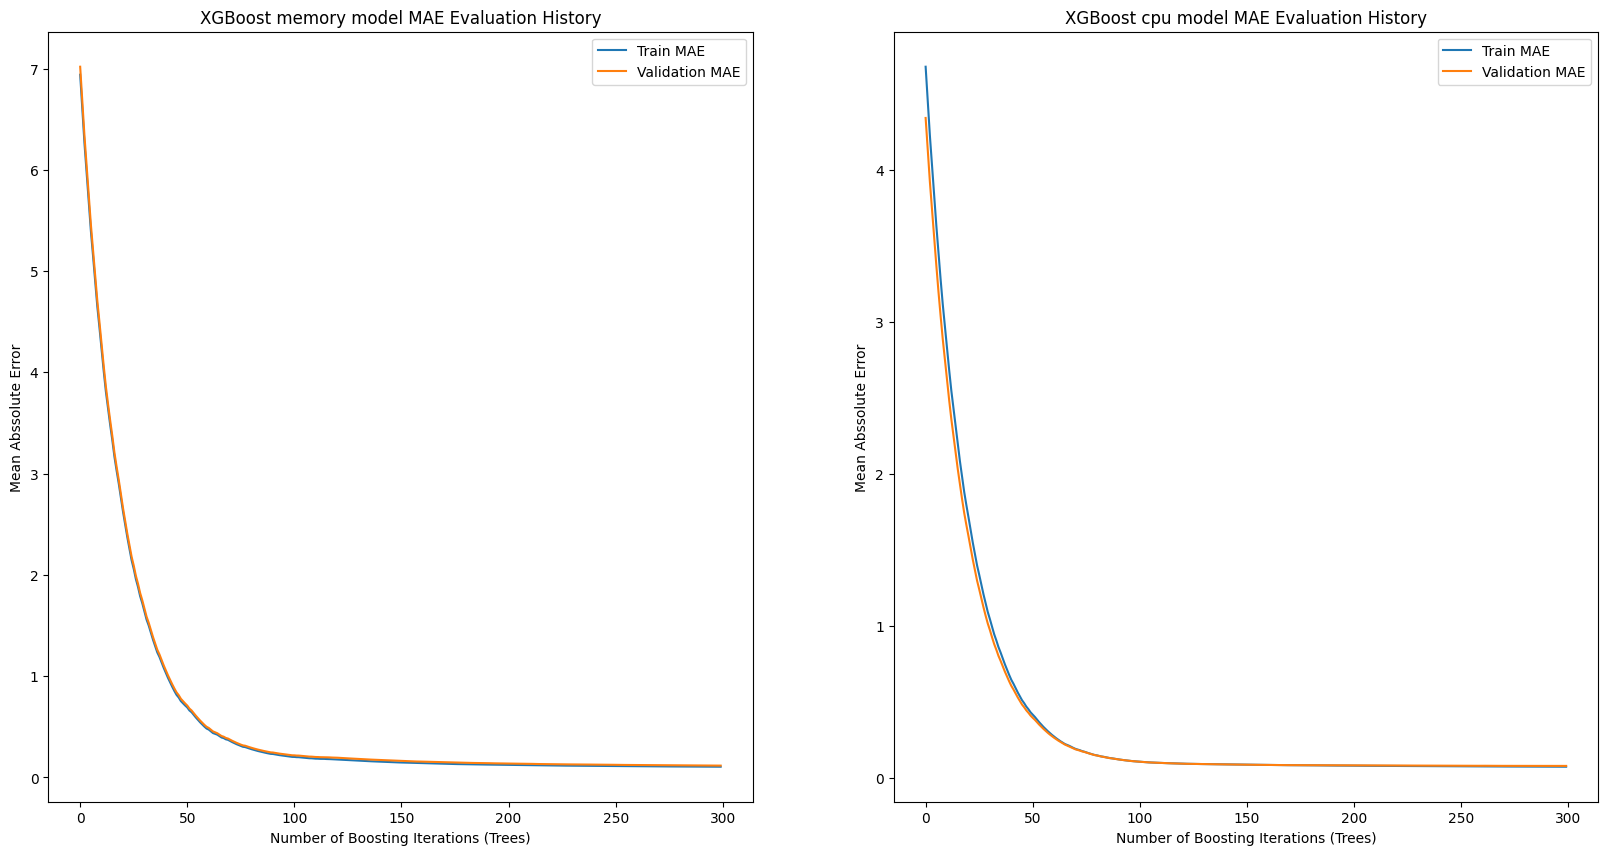

In [135]:
import matplotlib.pyplot as plt

cpu_results = cpu_model.evals_result()
memory_results = memory_model.evals_result()

memory_epochs = len(memory_results['validation_0']['mae'])
x_memory_axis = range(0, memory_epochs)
cpu_epochs = len(cpu_results['validation_0']['mae'])
x_cpu_axis = range(0, cpu_epochs)

fig , axs = plt.subplots(nrows=1,ncols=2, figsize=(20,10))

axs[0].plot(x_memory_axis, memory_results['validation_0']['mae'], label='Train MAE')
axs[0].plot(x_memory_axis, memory_results['validation_1']['mae'], label='Validation MAE')
axs[0].legend()
axs[0].set_ylabel('Mean Abssolute Error')
axs[0].set_xlabel('Number of Boosting Iterations (Trees)')
axs[0].set_title('XGBoost memory model MAE Evaluation History')

axs[1].plot(x_cpu_axis, cpu_results['validation_0']['mae'], label='Train MAE')
axs[1].plot(x_cpu_axis, cpu_results['validation_1']['mae'], label='Validation MAE')
axs[1].legend()
axs[1].set_ylabel('Mean Abssolute Error')
axs[1].set_xlabel('Number of Boosting Iterations (Trees)')
axs[1].set_title('XGBoost cpu model MAE Evaluation History')


plt.show()
fig.savefig("fig.png")

In [136]:


# =========================================================
# EVALUATION
# =========================================================

cpu_mae = mean_absolute_error(
    y_cpu_test,
    cpu_predictions
)

memory_mae = mean_absolute_error(
    y_memory_test,
    memory_predictions
)

cpu_rmse = root_mean_squared_error(
    y_cpu_test,
    cpu_predictions
)

memory_rmse = root_mean_squared_error(
    y_memory_test,
    memory_predictions
)
cpu_mae = mean_absolute_error(
    y_cpu_test,
    cpu_predictions
)

memory_mse = mean_squared_error(
    y_memory_test,
    memory_predictions
)
cpu_mse = mean_squared_error(
    y_cpu_test,
    cpu_predictions
)

memory_r2 = r2_score(
    y_memory_test,
    memory_predictions
)
cpu_r2 = r2_score(
    y_cpu_test,
    cpu_predictions
)

print("CPU MAE:", cpu_mae)
print("MEMORY MAE:", memory_mae)

print("CPU RMSE:", cpu_rmse)
print("MEMORY RMSE:", memory_rmse)

print("CPU MSE:", cpu_mse)
print("MEMORY MSE:", memory_mse)

print("CPU R2:", cpu_r2)
print("MEMORY R2:", memory_r2)

CPU MAE: 0.160598319378143
MEMORY MAE: 0.10931876825953399
CPU RMSE: 1.4681255238140178
MEMORY RMSE: 0.33115062391701455
CPU MSE: 2.1553925536741843
MEMORY MSE: 0.109660735720628
CPU R2: 0.977741322009477
MEMORY R2: 0.9990130156606294


In [137]:


# =========================================================
# SHOW RESULTS
# =========================================================

results = pd.DataFrame({
    "real_cpu": y_cpu_test.values,
    "predicted_cpu": cpu_predictions,

    "real_memory": y_memory_test.values,
    "predicted_memory": memory_predictions
})

print(results.head(20))

    real_cpu  predicted_cpu  real_memory  predicted_memory
0       0.32       0.321924         1.05          1.025840
1       0.32       0.321924         0.85          0.811669
2       0.33       0.329321         0.79          0.809708
3       0.32       0.321924         0.26          0.271789
4       0.32       0.321924         0.85          0.799221
5       0.32       0.321924         1.06          1.031810
6       0.32       0.321924         0.79          0.799217
7       0.35       0.347007         1.46          1.414637
8       0.31       0.314916         2.85          2.799767
9       0.31       0.314731         0.79          0.780683
10      0.32       0.321924         0.92          0.905871
11      0.31       0.313779         0.13          0.156307
12      0.32       0.321924         0.33          0.311085
13      0.31       0.313779         0.46          0.456023
14      0.31       0.313779         0.00          0.024597
15      0.31       0.313779         0.52          0.5021

In [138]:
# =========================================================
# PREDICT NEXT VALUES
# =========================================================

latest_row = X.iloc[-1:]

next_cpu = cpu_model.predict(latest_row)[0]
next_memory = memory_model.predict(latest_row)[0]

print("\nNEXT CPU PREDICTION:", next_cpu)
print("NEXT MEMORY PREDICTION:", next_memory)


NEXT CPU PREDICTION: 2.0948884
NEXT MEMORY PREDICTION: 13.500453


In [139]:
import pickle 

with open('/kaggle/working/cpu_model.pkl', 'wb') as file:
    pickle.dump(cpu_model, file)

with open('/kaggle/working/memory_model.pkl', 'wb') as file:
    pickle.dump(memory_model, file)